# Projektaufgabe: Werkzeugbruch-Erkennung mit Machine Learning

**Kurs:** Machine Learning  
**Semester:** SoSe 2026  
**Hochschule:** Hochschule Furtwangen University (HFU)

---

## 1. Motivation und Hintergrund

Beim **CNC-Fräsen** ist der Werkzeugbruch eines der kostspieligsten Ereignisse im
Fertigungsprozess. Ein gebrochenes Werkzeug führt zu Maschinenstillstand, Ausschuss
und im schlimmsten Fall zu Schäden an der Maschine. Eine frühzeitige, datenbasierte
Erkennung von Bruchrisiken kann die Produktionssicherheit erheblich verbessern.

Der synthetische Datensatz stammt aus einer physikalischen Simulation des Fräsprozesses.

---

## 2. Datensatz

### 2.1 Datei

```
werkzeugbruch_training.csv   ← Trainingsdatensatz (5 000 Einträge)
```

### 2.2 Spalten

| Spalte | Einheit | Beschreibung | Wertebereich |
|--------|---------|--------------|--------------|
| `depth_of_cut` | mm | Schnitttiefe $a_p$ | 0.5 – 5.0 |
| `feed_rate` | mm/U | Vorschub $f$ | 0.05 – 0.6 |
| `tool_wear_min` | min | Werkzeugverschleiß | 0 – 120 |
| `tool_breakage` | — | **Zielvariable** (0 = kein Bruch, 1 = Bruch) | {0, 1} |

### 2.3 Wichtige Eigenschaften

- **Klassenungleichgewicht:** Der Werkzeugbruch ist ein seltenes Ereignis.
  Die Bruchrate im Datensatz beträgt ca. **5 %**.
  Das bedeutet: Ein triviales Modell, das immer „kein Bruch" vorhersagt,
  erreicht bereits 95 % Accuracy — ist aber vollständig nutzlos.
- **Nichtlineare Grenze:** Die Trenngrenze zwischen Bruch und Nicht-Bruch
  ist in den Rohdaten **nicht linear**. Überlegen Sie, welche Transformation
  der Features die Trennbarkeit verbessern könnte.

---

## 3. Aufgabenstellung

### 3.1 Ziel

Entwickeln Sie ein **binäres Klassifikationsmodell**, das auf Basis der drei
Prozessparameter (`depth_of_cut`, `feed_rate`, `tool_wear_min`) vorhersagt,
ob ein **Werkzeugbruch** auftritt oder nicht.

### 3.2 Vorgehen

1. **Explorative Datenanalyse (EDA)**  
   Untersuchen Sie die Verteilungen der Features, die Bruchrate und
   mögliche Zusammenhänge zwischen Features und Zielvariable.

2. **Feature Engineering**  
   Welche Transformation(en) der Features könnten helfen?
   Begründen Sie Ihre Wahl und zeigen Sie den Effekt auf die Trennbarkeit.

3. **Modellauswahl und Training**  
   Trainieren Sie mindestens **ein** logistisches Regressionsmodell.
   Beachten Sie das Klassenungleichgewicht bei der Modellauswahl und Threshold-Wahl.

4. **Evaluation**  
   Die Performance Ihres Modells wird mit Hilfe des F1-Scores an einem
   Validierungsdatensatz gemessen. In Ihrem Notebook muss eine Funktion namens `predict_breakage(X)` existieren, die einen beliebigen Datensatz (ohne Zielvariable) im Format des Original-Dataframes akzeptiert und ein NumPy-Array mit den finalen Vorhersagen (0 oder 1) nach dem Threshold-Tuning zurückgibt.

5. **Koeffizienteninterpretation**  
   Lesen Sie die gelernten Koeffizienten (`coef_`, `intercept_`) Ihres Modells aus
   und interpretieren Sie diese inhaltlich:
   - Welche Features haben den größten Einfluss?
   - Stimmen Vorzeichen und Größenordnung mit Ihrer Erwartung überein?
   - Was sagt das Modell über den physikalischen Zusammenhang aus?

6. **Manuelle Implementierung**  
   Implementieren Sie das trainierte Modell **ohne sklearn** mithilfe der gelernten
   Koeffizienten und vergleichen Sie die Ergebnisse numerisch:

   $$p_i = \sigma\!\left(\mathbf{w}^\top \mathbf{x}_i + b\right) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x}_i + b)}}$$

   Zeigen Sie, dass Ihre manuelle Berechnung mit `model.predict_proba(X)` übereinstimmt
   (z. B. maximale absolute Abweichung < $10^{-10}$).

### 3.3 Bewertungsmetrik

Da der Datensatz stark unausgewogen ist, wird **nicht** die Accuracy verwendet.
Die primäre Metrik ist der **F1-Score der positiven Klasse (Werkzeugbruch = 1)**:

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

---

## 4. Abgabe

Abzugeben ist ein **Jupyter Notebook** mit:

- [ ] Explorativer Datenanalyse
- [ ] Feature Engineering mit Begründung
- [ ] Begründeter Modellwahl
- [ ] Dokumentiertem Training
- [ ] Visualisierung der Ergebnisse (Entscheidungsgrenze im Original-Feature-Raum)
- [ ] Koeffizienteninterpretation (Bedeutung der gelernten Gewichte)
- [ ] Manuelle Implementierung des Modells und numerischer Vergleich mit sklearn
- [ ] Kritische Reflexion: Wo liegen die Grenzen des Modells?

Erstellen Sie zusätzlich eine kleine Präsentation, mit deren Hilfe Sie die wesentlichen Erkenntisse ihres Modells in einem 10 minütigen Vortrag vorstellen. 

---

## 5. Hinweise

> 💡 **Threshold-Tuning:** Der Standard-Entscheidungsschwellwert von 0.5 ist bei
> stark unausgewogenen Klassen oft suboptimal. Untersuchen Sie, ob ein angepasster
> Schwellwert den F1-Score verbessert.

> 📊 **Visualisierung:** Visualisieren Sie nicht nur die Metriken, sondern auch die
> Entscheidungsgrenzen Ihres Modells (2-D-Schnitt durch den Feature-Raum).

---

## 6. Datensatz-Übersicht (Einstiegshilfe)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Datensatz laden ───────────────────────────────────────────────────────────
df = pd.read_csv('werkzeugbruch_training.csv')

print("=" * 55)
print("  Datensatz: werkzeugbruch_training.csv")
print("=" * 55)
print(f"\nShape      : {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"Bruchrate  : {df['tool_breakage'].mean():.2%}  "
      f"({df['tool_breakage'].sum()} Brüche / {len(df)} Samples)\n")

print("── Erste 5 Zeilen ───────────────────────────────────")
print(df.head().to_string(index=True))

print("\n── Statistische Kennzahlen (Features) ───────────────")
print(df[['depth_of_cut', 'feed_rate', 'tool_wear_min']].describe().round(3).to_string())

print("\n── Klassenverteilung ─────────────────────────────────")
vc = df['tool_breakage'].value_counts()
print(f"  Klasse 0 (kein Bruch): {vc[0]:5,}  ({vc[0]/len(df):.1%})")
print(f"  Klasse 1 (Bruch)     : {vc[1]:5,}  ({vc[1]/len(df):.1%})")

  Datensatz: werkzeugbruch_training.csv

Shape      : 5,000 Zeilen × 4 Spalten
Bruchrate  : 5.24%  (262 Brüche / 5000 Samples)

── Erste 5 Zeilen ───────────────────────────────────
   depth_of_cut  feed_rate  tool_wear_min  tool_breakage
0          1.22      0.191           66.7              0
1          3.46      0.254          102.8              0
2          3.23      0.183           22.8              0
3          2.89      0.280           73.4              0
4          1.62      0.314           31.5              0

── Statistische Kennzahlen (Features) ───────────────
       depth_of_cut  feed_rate  tool_wear_min
count      5000.000   5000.000       5000.000
mean          2.242      0.278         58.950
std           1.181      0.156         34.687
min           0.500      0.050          0.000
25%           1.270      0.143         28.400
50%           2.040      0.251         58.900
75%           3.072      0.403         88.600
max           4.990      0.600        120.000

── Kla

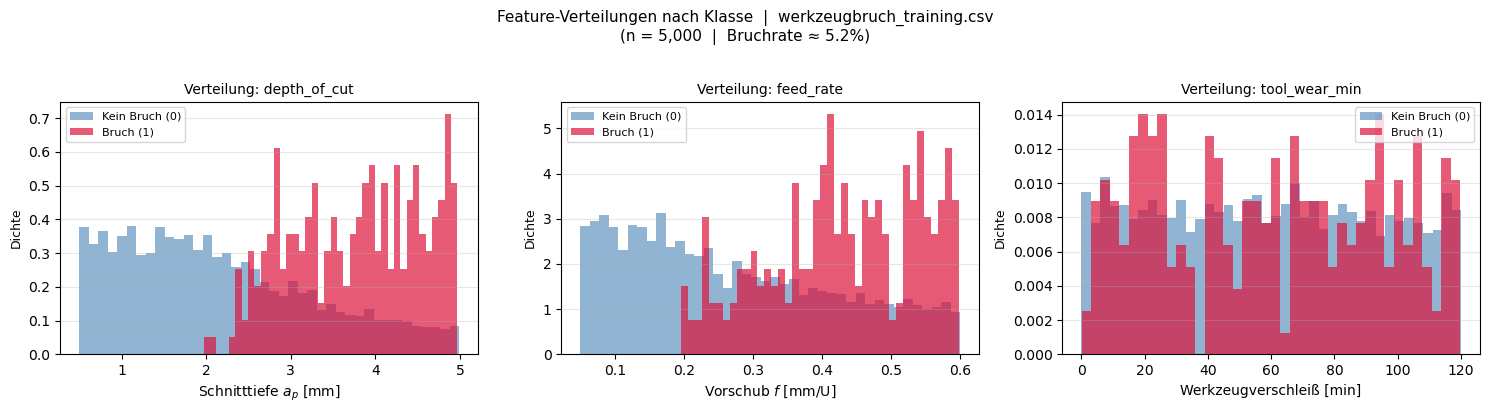

In [ ]:
# ── Visualisierung: Feature-Verteilungen + Bruchereignisse ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

feature_labels = {
    'depth_of_cut':  'Schnitttiefe $a_p$ [mm]',
    'feed_rate':     'Vorschub $f$ [mm/U]',
    'tool_wear_min': 'Werkzeugverschleiß [min]',
}

for ax, (col, xlabel) in zip(axes, feature_labels.items()):
    df0 = df[df['tool_breakage'] == 0][col]
    df1 = df[df['tool_breakage'] == 1][col]
    bins = 40

    ax.hist(df0, bins=bins, alpha=0.6, color='steelblue', label='Kein Bruch (0)', density=True)
    ax.hist(df1, bins=bins, alpha=0.7, color='crimson',   label='Bruch (1)',      density=True)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Dichte', fontsize=9)
    ax.set_title(f'Verteilung: {col}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Feature-Verteilungen nach Klasse  |  werkzeugbruch_training.csv\n'
    f'(n = {len(df):,}  |  Bruchrate ≈ {df["tool_breakage"].mean():.1%})',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()